In [74]:
import numpy as np

def make_web(n,k,kmin=0):

    

    # Input: n og k er ikke-negative heltal
    # Output: web er en dictionary med n nøgler.
    # Værdien af hver nøgle er en mængde, der er en delmængde af nøglerne.
    
    assert(k < n), "k skal være mindre end n (da man ikke kan linke til sig selv)"
    assert(kmin <= k), "kmin skal være mindre end eller lig med k"
    keys = [i for i in range(n)]# Fjern pass og INDSÆT KODE HER - definér n nøgler fra 0 til n-1 
    web = dict()
    #print(keys)
    for j in keys:
        numlinks = np.random.randint(kmin,k)# INDSÆT KODE HER - generér et tilfældigt tal mellem kmin og k
        web[j] = set() # INDSÆT KODE HER - Vælg et antal links (numlinks) fra de andre sider, undgå at vælge den nuværende side (j) og sørg for, at der ikke er duplikatlinks
        links = []
        for _ in range(numlinks):
            link = np.random.choice(keys)
            if link != j:
                links.append(int(link))
        web[j] = set(links)
    return web

In [75]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(web):
    
    # Input: netværk som dictionary
    # Output: Netværk visualiseret som graf

    G = nx.DiGraph()
    for node, links in web.items():
        G.add_node(node)
        for link in links:
            G.add_edge(node, link)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_size=8, arrows=True)

    # INDSÆT KODE HER

    plt.show()

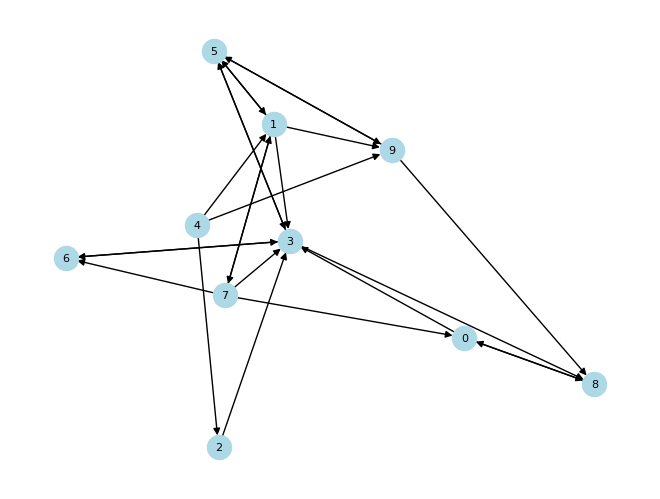

In [78]:
visualize_graph(web)

In [77]:
web = make_web(10, 6)
web

{0: {3, 8},
 1: {3, 5, 7, 9},
 2: {3},
 3: {5, 6, 8},
 4: {1, 2, 9},
 5: {1, 3, 9},
 6: {3},
 7: {0, 1, 3, 6},
 8: {0},
 9: {5, 8}}

In [79]:

def surf_step(web, startpage):
    
    # Input: Et netværk som dictionary og en start side
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict()

    for page, links in web.items():
        if links == set():
            distribution[page] = [1/len(web) for i in range(len(web))]
        else:
            distribution[page] = [0 for i in range(len(web))]
            for link in links:
                distribution[page][link] += 1/len(links)

    
    return distribution[startpage]

In [80]:
distribution = surf_step(web, 2)

In [82]:
def random_surf(web, n):

    # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()]
    start_page = np.random.choice(starts)
    for i in range(n):
        distribution = surf_step(web, start_page)
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution)
        #print(start_page)
        if start_page not in ranking.keys():
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n
    
#hello
    #ranking=dict()
 
    # INDSÆT KODE HER

    return ranking

In [88]:
random_surf(web, 10000000)

{9: 0.0503528,
 8: 0.2193235,
 0: 0.2219686,
 3: 0.250036,
 5: 0.1192072,
 6: 0.0860568,
 1: 0.0424346,
 7: 0.0106205}

In [ ]:
#print("test123")